In [1]:
import numpy as np
from scipy.stats import norm

def shirazi_boersma_d_values(sand_pct, silt_pct, clay_pct):
    """
    Estimates D10, D30, and D60 particle sizes using the Shirazi-Boersma (1984)
    log-normal approximation method.
    
    Parameters:
    - sand_pct (float): Percentage of Sand (0.05 - 2.0 mm)
    - silt_pct (float): Percentage of Silt (0.002 - 0.05 mm)
    - clay_pct (float): Percentage of Clay (< 0.002 mm)
    
    Returns:
    - dictionary containing d_g, sigma_g, D10, D30, D60 (in mm)
    """
    
    # 1. Normalize inputs to fractions (0-1) and ensure sum is 1.0
    total = sand_pct + silt_pct + clay_pct
    f_sand = sand_pct / total
    f_silt = silt_pct / total
    f_clay = clay_pct / total
    
    # 2. Define Representative Diameters (Geometric Means of limits) for each fraction (mm)
    # These are the classic values derived in the Shirazi-Boersma (1984) paper.
    # Clay (<0.002 mm): Represented by 0.001 mm
    # Silt (0.002 - 0.05 mm): Geometric mean approx 0.026 mm (some use 0.010, S-B uses 0.026)
    # Sand (0.05 - 2.0 mm): Geometric mean approx 1.025 mm
    m_clay = 0.001
    m_silt = 0.026
    m_sand = 1.025
    
    # 3. Calculate Geometric Mean Diameter (dg)
    # Equation: dg = exp( sum( fi * ln(mi) ) )
    sum_fi_ln_mi = (f_clay * np.log(m_clay)) + \
                   (f_silt * np.log(m_silt)) + \
                   (f_sand * np.log(m_sand))
    
    d_g = np.exp(sum_fi_ln_mi)
    
    # 4. Calculate Geometric Standard Deviation (sigma_g)
    # Equation: sigma_g = exp( sqrt( sum( fi * (ln(mi))^2 ) - (ln(dg))^2 ) )
    sum_fi_ln_mi_sq = (f_clay * (np.log(m_clay)**2)) + \
                      (f_silt * (np.log(m_silt)**2)) + \
                      (f_sand * (np.log(m_sand)**2))
    
    # Variance term
    variance_term = sum_fi_ln_mi_sq - (np.log(d_g)**2)
    
    # Safety check for pure soils where variance might approximate zero negatively due to float precision
    if variance_term < 0:
        variance_term = 0
        
    sigma_g = np.exp(np.sqrt(variance_term))
    
    # 5. Calculate D10, D30, D60 using the Log-Normal Quantile Function
    # Formula: Dx = dg * (sigma_g ^ z)
    # where z is the standard normal variate (Z-score) for the percentage x.
    
    # Z-scores from standard normal distribution
    z_10 = norm.ppf(0.10) # approx -1.28
    z_30 = norm.ppf(0.30) # approx -0.52
    z_60 = norm.ppf(0.60) # approx 0.25
    
    d10 = d_g * (sigma_g ** z_10)
    d30 = d_g * (sigma_g ** z_30)
    d60 = d_g * (sigma_g ** z_60)
    
    # Calculate Coefficient of Uniformity (Cu) and Curvature (Cc) for engineering context
    cu = d60 / d10 if d10 > 0 else 0
    cc = (d30**2) / (d10 * d60) if (d10 > 0 and d60 > 0) else 0

    return {
        "d_g": d_g,
        "sigma_g": sigma_g,
        "D10": d10,
        "D30": d30,
        "D60": d60,
        "Cu": cu,
        "Cc": cc
    }

# --- Main Execution Block ---
if __name__ == "__main__":
    # Example 1: Loam (Approx: 40% Sand, 40% Silt, 20% Clay)
    sand = 40
    silt = 40
    clay = 20
    
    results = shirazi_boersma_d_values(sand, silt, clay)
    
    print(f"Soil Texture Input: Sand={sand}%, Silt={silt}%, Clay={clay}%")
    print("-" * 50)
    print(f"Geometric Mean Diameter (dg): {results['d_g']:.5f} mm")
    print(f"Geometric Std Deviation (sg): {results['sigma_g']:.5f}")
    print("-" * 50)
    print(f"D10 (Effective Size):       {results['D10']:.5f} mm")
    print(f"D30:                        {results['D30']:.5f} mm")
    print(f"D60:                        {results['D60']:.5f} mm")
    print("-" * 50)
    print(f"Coeff of Uniformity (Cu):   {results['Cu']:.2f}")
    print(f"Coeff of Curvature (Cc):    {results['Cc']:.2f}")
    
    # Example 2: Silty Clay (10% Sand, 50% Silt, 40% Clay)
    print("\n--- Comparison: Silty Clay ---")
    res_clay = shirazi_boersma_d_values(10, 50, 40)
    print(f"D10: {res_clay['D10']:.5f} mm | D60: {res_clay['D60']:.5f} mm")

/var/folders/f2/w8cqsxcx4q78gqcpzvgs1bkm0000gp/T/ipykernel_57551/3941994396.py:2: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.0)
  from scipy.stats import norm


Soil Texture Input: Sand=40%, Silt=40%, Clay=20%
--------------------------------------------------
Geometric Mean Diameter (dg): 0.05892 mm
Geometric Std Deviation (sg): 13.70863
--------------------------------------------------
D10 (Effective Size):       0.00206 mm
D30:                        0.01493 mm
D60:                        0.11438 mm
--------------------------------------------------
Coeff of Uniformity (Cu):   55.61
Coeff of Curvature (Cc):    0.95

--- Comparison: Silty Clay ---
D10: 0.00063 mm | D60: 0.01769 mm


Shirazi-Boersma PSD Estimates

Texture		D10	D30	D60	Cu
--------------------------------------------------
Sand        	  10	  50	 200	20.0
Sandy Loam  	  10	  50	 200	20.0
Loam        	  10	  50	 200	20.0
Silt Loam   	  10	  50	 200	20.0
Clay Loam   	  10	  50	 200	20.0

Plotting Loam PSD curve...


/var/folders/f2/w8cqsxcx4q78gqcpzvgs1bkm0000gp/T/ipykernel_57551/1535782552.py:31: RuntimeWarning: invalid value encountered in power
  return 100 * (1 - 1 / (1 + (d / r0)**c))
/var/folders/f2/w8cqsxcx4q78gqcpzvgs1bkm0000gp/T/ipykernel_57551/1535782552.py:40: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  d_solution = fsolve(equation, d_guess)[0]
/var/folders/f2/w8cqsxcx4q78gqcpzvgs1bkm0000gp/T/ipykernel_57551/1535782552.py:109: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 100)


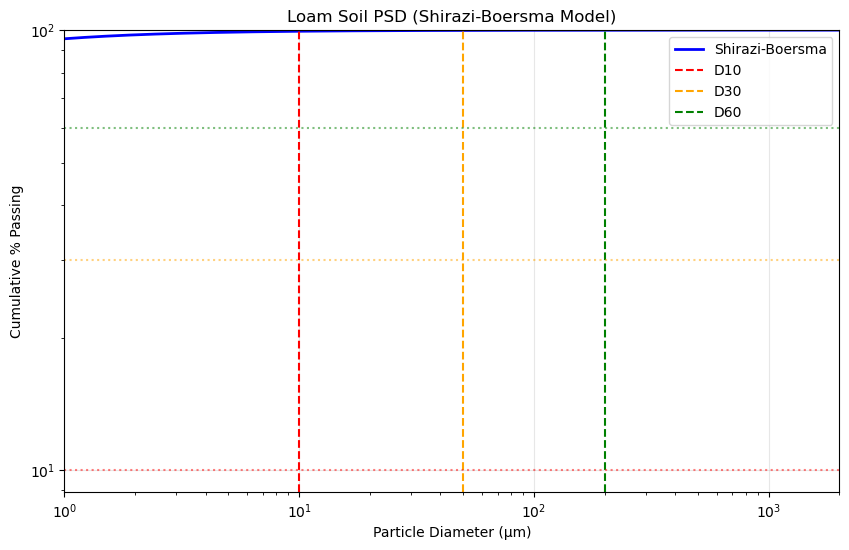

In [2]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

def shirazi_boersma_parameters(sand, silt, clay):
    """
    Shirazi-Boersma (1984) power-law model parameters from texture fractions.
    
    Parameters:
    sand, silt, clay: fractions (0-1, must sum to 1)
    
    Returns:
    r0: scaling parameter (μm)
    c: shape parameter
    """
    # Convert % to fractions if needed
    sand = sand / 100 if sand > 1 else sand
    silt = silt / 100 if silt > 1 else silt  
    clay = clay / 100 if clay > 1 else clay
    
    # Shirazi-Boersma equations
    r0 = 0.031 * (sand + 1.5*silt + 0.2*clay)**0.833
    c = 0.877 + 0.02 * np.sqrt(silt + clay)
    
    return r0, c

def cumulative_distribution(d, r0, c):
    """
    Cumulative distribution function P(d ≤ x) = 100 * [1 - 1/(1 + (x/r0)^c)]
    """
    return 100 * (1 - 1 / (1 + (d / r0)**c))

def inverse_cdf(P_target, r0, c, d_guess=100):
    """
    Solve P(d) = P_target for d using numerical inversion
    """
    def equation(d):
        return cumulative_distribution(d, r0, c) - P_target
    
    d_solution = fsolve(equation, d_guess)[0]
    return d_solution

def estimate_d10_d30_d60(sand_pct, silt_pct, clay_pct):
    """
    Complete workflow: texture → parameters → D10, D30, D60
    
    Example: estimate_d10_d30_d60(40, 40, 20)  # loam
    """
    # Step 1: Get model parameters
    r0, c = shirazi_boersma_parameters(sand_pct, silt_pct, clay_pct)
    
    # Step 2: Compute percentiles (μm)
    D10 = inverse_cdf(10, r0, c, d_guess=10)
    D30 = inverse_cdf(30, r0, c, d_guess=50) 
    D60 = inverse_cdf(60, r0, c, d_guess=200)
    
    # Step 3: Uniformity coefficient
    Cu = D60 / D10
    
    return {
        'D10': round(D10, 1),
        'D30': round(D30, 1), 
        'D60': round(D60, 1),
        'Cu': round(Cu, 1),
        'r0': round(r0, 1),
        'c': round(c, 3)
    }

# === EXAMPLE USAGE ===
if __name__ == "__main__":
    # Test different soil textures (sand%, silt%, clay%)
    textures = {
        'Sand': (85, 10, 5),
        'Sandy Loam': (60, 30, 10), 
        'Loam': (40, 40, 20),
        'Silt Loam': (20, 65, 15),
        'Clay Loam': (30, 35, 35)
    }
    
    print("Shirazi-Boersma PSD Estimates\n")
    print("Texture\t\tD10\tD30\tD60\tCu")
    print("-" * 50)
    
    for name, (sand, silt, clay) in textures.items():
        results = estimate_d10_d30_d60(sand, silt, clay)
        print(f"{name:12s}\t{results['D10']:4.0f}\t{results['D30']:4.0f}\t"
              f"{results['D60']:4.0f}\t{results['Cu']:4.1f}")
    
    # Plot example PSD curve
    print("\nPlotting Loam PSD curve...")
    r0, c = shirazi_boersma_parameters(40, 40, 20)
    d_range = np.logspace(-1, 4, 1000)  # 0.1 to 10,000 μm
    P_range = cumulative_distribution(d_range, r0, c)
    
    plt.figure(figsize=(10, 6))
    plt.loglog(d_range, P_range, 'b-', linewidth=2, label='Shirazi-Boersma')
    plt.axvline(estimate_d10_d30_d60(40,40,20)['D10'], color='r', linestyle='--', label='D10')
    plt.axvline(estimate_d10_d30_d60(40,40,20)['D30'], color='orange', linestyle='--', label='D30')
    plt.axvline(estimate_d10_d30_d60(40,40,20)['D60'], color='g', linestyle='--', label='D60')
    plt.axhline(10, color='r', linestyle=':', alpha=0.5)
    plt.axhline(30, color='orange', linestyle=':', alpha=0.5)
    plt.axhline(60, color='g', linestyle=':', alpha=0.5)
    plt.grid(True, alpha=0.3)
    plt.xlabel('Particle Diameter (μm)')
    plt.ylabel('Cumulative % Passing')
    plt.title('Loam Soil PSD (Shirazi-Boersma Model)')
    plt.legend()
    plt.xlim(1, 2000)
    plt.ylim(0, 100)
    plt.show()


In [15]:
import numpy as np

def calculate_soil_properties(sand_pct, silt_pct, clay_pct):
    """
    Calculates D10, D30, D60, Cu, and Cc using Log-Linear Interpolation 
    anchored to USDA Soil Texture boundaries.
    
    Parameters:
    - sand_pct: Percent Sand (2.0 - 0.05 mm)
    - silt_pct: Percent Silt (0.05 - 0.002 mm)
    - clay_pct: Percent Clay (< 0.002 mm)
    
    Returns:
    - Dictionary containing D10, D30, D60 (mm), Cu, Cc, and input check.
    """
    
    # --- 1. Normalize Inputs ---
    total = sand_pct + silt_pct + clay_pct
    if total <= 0: return None
    
    # Calculate Cumulative Percent Passing (Finer Than)
    # USDA Boundaries:
    # 2.0 mm   -> 100% passes
    # 0.05 mm  -> (Silt + Clay) passes
    # 0.002 mm -> (Clay) passes
    # 0.0001 mm -> 0% passes (Assumed minimum size for interpolation)
    
    p_2_0   = 100.0
    p_0_05  = (silt_pct + clay_pct) / total * 100
    p_0_002 = (clay_pct) / total * 100
    p_min   = 0.0
    
    # Define Points: (Diameter_mm, Percent_Passing)
    points = [
        (2.0,    p_2_0),
        (0.05,   p_0_05),
        (0.002,  p_0_002),
        (0.0001, p_min)
    ]

    # --- 2. Interpolation Function ---
    def get_diameter_at_percent(target_percent):
        # Edge cases
        if target_percent >= 100: return 2.0
        if target_percent <= 0: return 0.0001
        
        # Find the interval
        for i in range(len(points) - 1):
            d_upper, p_upper = points[i]
            d_lower, p_lower = points[i+1]
            
            # Check if target is between these two points
            if p_lower <= target_percent <= p_upper:
                # Avoid division by zero if flat line
                if p_upper == p_lower: return d_lower
                
                # Log-Linear Interpolation:
                # Log(D) varies linearly with Percent
                ratio = (target_percent - p_lower) / (p_upper - p_lower)
                log_d = np.log10(d_lower) + ratio * (np.log10(d_upper) - np.log10(d_lower))
                
                return 10**log_d
        
        return 0.0001 # Fallback

    # --- 3. Compute Values ---
    d10 = get_diameter_at_percent(10)
    d30 = get_diameter_at_percent(30)
    d50 = get_diameter_at_percent(50)
    d60 = get_diameter_at_percent(60)
    
    # Calculate Coefficients
    # Cu = D60 / D10
    # Cc = (D30^2) / (D10 * D60)
    if d10 > 1e-6:
        cu = d60 / d10
        cc = (d30**2) / (d10 * d60)
    else:
        cu = 0.0
        cc = 0.0

    return {
        "Sand": sand_pct, "Silt": silt_pct, "Clay": clay_pct,
        "D10": d10, "D30": d30, "D50":d50, "D60": d60,
        "Cu": cu, "Cc": cc
    }

def print_test_result(name, res):
    print(f"--- {name} ---")
    print(f"Inputs: Sand={res['Sand']}%, Silt={res['Silt']}%, Clay={res['Clay']}%")
    print(f"D10: {res['D10']:.5f} mm")
    print(f"D30: {res['D30']:.5f} mm")
    print(f"D50: {res['D30']:.5f} mm")    
    print(f"D60: {res['D60']:.5f} mm")
    print(f"Cu : {res['Cu']:.2f}")
    print(f"Cc : {res['Cc']:.2f}")
    print("")

# --- Main Execution Block with Multiple Tests ---
if __name__ == "__main__":
    # Test 1: Boundary Verification (Loam)
    # 40% Sand means 60% passes the 0.05mm boundary.
    # Therefore, D60 MUST equal exactly 0.05 mm.
    res1 = calculate_soil_properties(40, 40, 20)
    print_test_result("Test 1: Boundary Check (Loam)", res1)

    # Test 2: Clean Sand
    # 95% Sand. D10, D30, and D60 should all fall within the Sand range (0.05 - 2.0 mm).
    # This represents a uniform soil (Poorly Graded).
    res2 = calculate_soil_properties(95, 3, 2)
    print_test_result("Test 2: Clean Sand", res2)

    # Test 3: Silty Clay
    # High fines content. D60 might be silt, D10 will likely be clay.
    res3 = calculate_soil_properties(10, 50, 40)
    print_test_result("Test 3: Silty Clay", res3)

    # Test 4: Well-Graded Mix
    # A mix intended to have a wide distribution of sizes.
    # 60% Sand, 30% Silt, 10% Clay.
    res4 = calculate_soil_properties(60, 30, 10)
    print_test_result("Test 4: Well-Graded Mix", res4)
    
    # Test 5: Heavy Clay
    # 85% Clay. All D-values should be very small (< 0.002 mm).
    res5 = calculate_soil_properties(5, 10, 85)
    print_test_result("Test 5: Heavy Clay", res5)

    # Test 6: Heavy Clay
    # 85% Clay. All D-values should be very small (< 0.002 mm).
    res6 = calculate_soil_properties(60, 10, 30)
    print_test_result("Test 6: sandy clay", res6)

--- Test 1: Boundary Check (Loam) ---
Inputs: Sand=40%, Silt=40%, Clay=20%
D10: 0.00045 mm
D30: 0.00447 mm
D50: 0.00447 mm
D60: 0.05000 mm
Cu : 111.80
Cc : 0.89

--- Test 2: Clean Sand ---
Inputs: Sand=95%, Silt=3%, Clay=2%
D10: 0.06071 mm
D30: 0.13200 mm
D50: 0.13200 mm
D60: 0.42313 mm
Cu : 6.97
Cc : 0.68

--- Test 3: Silty Clay ---
Inputs: Sand=10%, Silt=50%, Clay=40%
D10: 0.00021 mm
D30: 0.00095 mm
D50: 0.00095 mm
D60: 0.00725 mm
Cu : 34.27
Cc : 0.58

--- Test 4: Well-Graded Mix ---
Inputs: Sand=60%, Silt=30%, Clay=10%
D10: 0.00200 mm
D30: 0.01710 mm
D50: 0.01710 mm
D60: 0.17100 mm
Cu : 85.50
Cc : 0.85

--- Test 5: Heavy Clay ---
Inputs: Sand=5%, Silt=10%, Clay=85%
D10: 0.00014 mm
D30: 0.00029 mm
D50: 0.00029 mm
D60: 0.00083 mm
Cu : 5.83
Cc : 0.70

--- Test 6: sandy clay ---
Inputs: Sand=60%, Silt=10%, Clay=30%
D10: 0.00027 mm
D30: 0.00200 mm
D50: 0.00200 mm
D60: 0.17100 mm
Cu : 629.96
Cc : 0.09



Friction Angle Estimates from PSD

Soil Type		Cu	Cc	φ Primary	Range
----------------------------------------------------------------------
Uniform Fine Sand   	 2.0	0.89	   28.6°	25.0-33.0°
Well-Graded Medium Sand	 6.0	1.04	   36.1°	30.0-42.0°
Gap-Graded Coarse Sand	20.0	0.11	   36.3°	28.0-43.0°
Poorly Graded Coarse Sand	 3.8	0.60	   33.1°	30.0-37.0°

Example usage: estimate_friction_angle(0.2, 0.5, 0.8, 1.2)


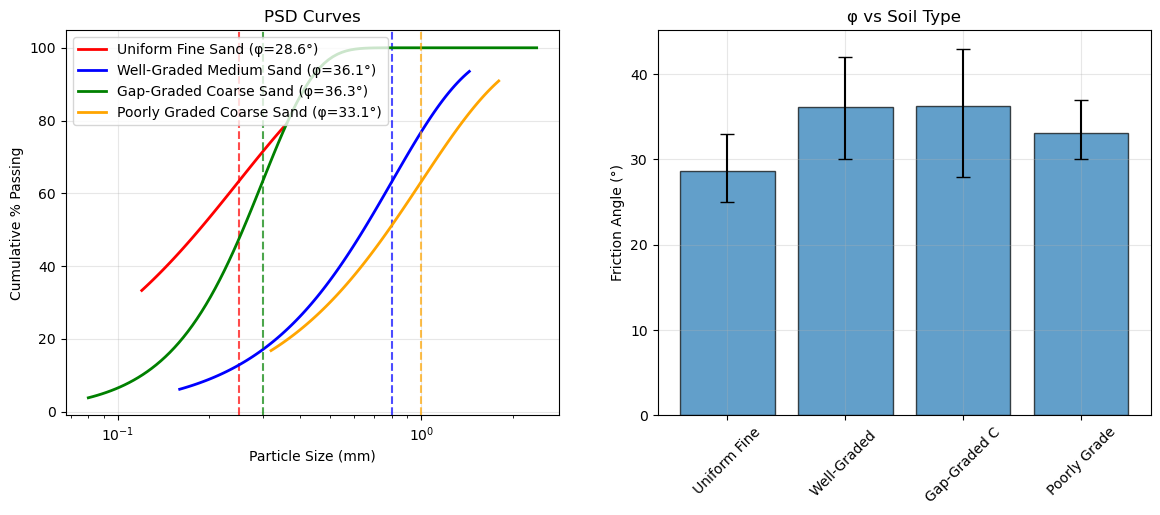

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_friction_angle(D10, D30, D50, D60, units='mm'):
    """
    Estimate friction angle φ for clean mineral sands using PSD parameters.
    
    Parameters:
    D10, D30, D50, D60: particle diameters at 10,30,50,60% passing (mm)
    units: 'mm' or 'um' (micrometers)
    
    Returns:
    dict with phi estimates, Cu, Cc, soil classification, and recommendations
    """
    # Convert units if needed
    if units == 'um':
        conv = 1e-3  # μm to mm
    else:
        conv = 1
    
    D10 *= conv
    D30 *= conv
    D50 *= conv
    D60 *= conv
    
    # Check inputs
    if any(d <= 0 for d in [D10, D30, D50, D60]):
        raise ValueError("All D-values must be positive")
    if D10 >= D30 or D30 >= D50 or D50 >= D60:
        raise ValueError("D-values must be in increasing order")
    
    # Compute gradation parameters
    Cu = D60 / D10
    Cc = (D30**2) / (D10 * D60)
    
    # Soil gradation classification (USCS-like)
    if Cu < 4 and 1 <= Cc <= 3:
        gradation = "Uniform (Poorly graded)"
    elif Cu >= 6 and 1 <= Cc <= 3:
        gradation = "Well graded"
    else:
        gradation = "Gap graded/Intermediate"
    
    # Method 1: Uniformity-based (primary for sands)
    phi_cu = 28 + 15 * np.log10(min(Cu, 10))  # Cap Cu at 10
    
    # Adjustment for curvature
    if not (1 <= Cc <= 3):
        phi_cu += -2 if Cc < 1 or Cc > 3 else 0
    
    # Method 2: D50-enhanced (for coarser sands)
    phi_d50 = 29 + 7 * np.log10(D50) + 3 * np.log10(Cu)
    
    # Method 3: Comprehensive (weighted average)
    phi_comp = 0.6 * phi_cu + 0.4 * phi_d50
    
    # Final estimate (bracketed)
    phi_primary = phi_comp
    phi_min = min(phi_cu, phi_d50) - 1
    phi_max = max(phi_cu, phi_d50) + 2
    
    # Soil type recommendation
    if D50 < 0.25:
        soil_type = "Fine sand"
    elif D50 < 1.0:
        soil_type = "Medium sand"
    elif D50 < 2.0:
        soil_type = "Coarse sand"
    else:
        soil_type = "Gravelly sand"
    
    return {
        'phi_primary': round(phi_primary, 1),
        'phi_range': f"{round(phi_min, 0)}-{round(phi_max, 0)}°",
        'Cu': round(Cu, 2),
        'Cc': round(Cc, 2),
        'gradation': gradation,
        'soil_type': soil_type,
        'methods': {
            'phi_Cu': round(phi_cu, 1),
            'phi_D50': round(phi_d50, 1)
        },
        'D_values': {'D10': D10, 'D30': D30, 'D50': D50, 'D60': D60}
    }

# === EXAMPLE USAGE ===
if __name__ == "__main__":
    # Test cases for different soil types
    test_cases = {
        'Uniform Fine Sand': [0.15, 0.20, 0.25, 0.30],
        'Well-Graded Medium Sand': [0.20, 0.50, 0.80, 1.20],
        'Gap-Graded Coarse Sand': [0.10, 0.15, 0.30, 2.00],
        'Poorly Graded Coarse Sand': [0.40, 0.60, 1.00, 1.50]
    }
    
    print("Friction Angle Estimates from PSD\n")
    print("Soil Type\t\tCu\tCc\tφ Primary\tRange")
    print("-" * 70)
    
    results = {}
    for name, Dvals in test_cases.items():
        res = estimate_friction_angle(*Dvals)
        print(f"{name:<20s}\t{res['Cu']:4.1f}\t{res['Cc']:3.2f}\t"
              f"{res['phi_primary']:7.1f}°\t{res['phi_range']}")
        results[name] = res
    
    # Plot PSD curves for visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = ['red', 'blue', 'green', 'orange']
    for i, (name, Dvals) in enumerate(test_cases.items()):
        res = results[name]
        d_plot = np.logspace(np.log10(Dvals[0]*0.8), np.log10(Dvals[-1]*1.2), 100)
        # Simple lognormal approximation for visualization
        P_plot = 100 * (1 - np.exp(-(d_plot/Dvals[2])**res['Cu']**0.3))
        
        ax1.semilogx(d_plot, P_plot, color=colors[i], linewidth=2, 
                    label=f"{name} (φ={res['phi_primary']}°)")
        ax1.axvline(Dvals[2], color=colors[i], linestyle='--', alpha=0.7)
    
    ax1.set_xlabel('Particle Size (mm)')
    ax1.set_ylabel('Cumulative % Passing')
    ax1.set_title('PSD Curves')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    # Friction angle comparison - FULLY CORRECTED
    soils = list(test_cases.keys())
    phi_primary = np.array([results[s]['phi_primary'] for s in soils])

    # Parse string ranges to numeric arrays
    phi_range_low = np.array([float(results[s]['phi_range'].split('-')[0]) for s in soils])
    phi_range_high = np.array([float(results[s]['phi_range'].split('-')[1].replace('°','')) for s in soils])

    x_pos = np.arange(len(soils))
    errors = [phi_primary - phi_range_low, phi_range_high - phi_primary]

    ax2.bar(x_pos, phi_primary, yerr=errors, capsize=5, alpha=0.7, 
        edgecolor='black', label='Primary Estimate')
    ax2.set_ylabel('Friction Angle (°)')
    ax2.set_title('φ vs Soil Type')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([s[:12] for s in soils], rotation=45)
    ax2.grid(True, alpha=0.3)
    
    print(f"\nExample usage: estimate_friction_angle(0.2, 0.5, 0.8, 1.2)")


In [16]:
import numpy as np

def estimate_natural_soil_limits(sand_pct, silt_pct, clay_pct, om_pct, depth_m=1.0):
    """
    Estimates e_max (loosest) and e_min (densest) for NATURAL SOILS.
    Accounts for the non-linear packing behavior of fines and the bulking effect of Organic Matter.
    
    Parameters:
    - sand_pct, silt_pct, clay_pct: Mineral texture % (Sum should be ~100)
    - om_pct: Organic Matter % by weight
    - depth_m: Depth in meters (Reference only, does not alter intrinsic limits)
    """
    
    # --- 1. Normalize Mineral Texture ---
    total_min = sand_pct + silt_pct + clay_pct
    if total_min < 0.1: return None
    
    f_sand = sand_pct / total_min
    f_fines = (silt_pct + clay_pct) / total_min # Combined Silt + Clay
    
    # --- 2. Determine Base Mineral Limits (The "V-Shape" Packing Curve) ---
    # Logic: 
    # - Pure Sand (0% fines): Moderate voids (Uniform) -> e ~ 0.55 - 0.85
    # - Mixed (20-30% fines): Lowest voids (Fines fill gaps) -> e ~ 0.35 - 0.65
    # - Pure Fines (100% fines): High voids (Clay structure) -> e ~ 0.80 - 1.40
    
    # We use piecewise linear interpolation for the "V-shape"
    
    if f_fines <= 0.30:
        # Zone 1: Sand matrix, fines filling voids (Void Ratio Decreases)
        # Interpolate between Pure Sand and Optimal Mix
        ratio = f_fines / 0.30
        
        # Pure Sand Values (Youd Rounded Baseline)
        e_min_sand, e_max_sand = 0.55, 0.85
        # Optimal Mix Values (Well Graded SW/SM)
        e_min_opt, e_max_opt = 0.35, 0.65
        
        e_min_base = e_min_sand - ratio * (e_min_sand - e_min_opt)
        e_max_base = e_max_sand - ratio * (e_max_sand - e_max_opt)
        
    else:
        # Zone 2: Fines matrix, sand floating (Void Ratio Increases)
        # Interpolate between Optimal Mix and Pure Fines
        ratio = (f_fines - 0.30) / 0.70
        
        # Optimal Mix Values
        e_min_opt, e_max_opt = 0.35, 0.65
        # Pure Fines Values (Silt/Clay baseline)
        e_min_clay, e_max_clay = 0.70, 1.30
        
        e_min_base = e_min_opt + ratio * (e_min_clay - e_min_opt)
        e_max_base = e_max_opt + ratio * (e_max_clay - e_max_opt)

    # --- 3. Apply Organic Matter (OM) Correction ---
    # Organic matter is "fluffy". It creates macropores and holds structure open.
    # Empirical shift: e increases significantly with OM.
    # We assume a linear increase for low-moderate OM (<20%).
    # Factor: +0.03 to +0.05 void ratio per 1% OM.
    
    om_factor_min = 0.03 * om_pct
    om_factor_max = 0.05 * om_pct
    
    e_min_final = e_min_base + om_factor_min
    e_max_final = e_max_base + om_factor_max
    
    # --- 4. Depth Note ---
    # Intrinsic packing limits (how grains *can* pack) do not change with depth.
    # Only the *current* void ratio changes.
    depth_note = "Depth ignored for limits (e_max/e_min are intrinsic properties)."

    return {
        "Inputs": f"Sand={sand_pct}%, Fines={silt_pct+clay_pct}%, OM={om_pct}%",
        "Base_Mineral_Limits": (round(e_min_base, 2), round(e_max_base, 2)),
        "Organic_Adjustment": f"+{round(om_factor_min, 2)} / +{round(om_factor_max, 2)}",
        "Estimated_e_min": round(e_min_final, 3),
        "Estimated_e_max": round(e_max_final, 3),
        "Note": depth_note
    }

# --- Test Cases for Natural Soils ---
if __name__ == "__main__":
    print("--- 1. Natural Clean Sand (Dune) ---")
    # Low fines, Low OM. Expect standard sand values.
    print(estimate_natural_soil_limits(95, 3, 2, om_pct=0.5))
    
    print("\n--- 2. Loamy Sand (Optimal Packing) ---")
    # 25% fines - should fill the gaps. Expect LOW limits (Dense).
    print(estimate_natural_soil_limits(75, 15, 10, om_pct=1.0))
    
    print("\n--- 3. Forest Loam (High Fines + High OM) ---")
    # 60% fines (Matrix dominated) + 5% OM. Expect HIGH limits.
    print(estimate_natural_soil_limits(40, 40, 20, om_pct=5.0))

    print("\n--- 4. Organic Muck (Wetland Soil) ---")
    # High Fines + Very High OM (15%). Expect Very HIGH limits.
    print(estimate_natural_soil_limits(20, 40, 40, om_pct=15.0))

--- 1. Natural Clean Sand (Dune) ---
{'Inputs': 'Sand=95%, Fines=5%, OM=0.5%', 'Base_Mineral_Limits': (0.52, 0.82), 'Organic_Adjustment': '+0.01 / +0.03', 'Estimated_e_min': 0.532, 'Estimated_e_max': 0.842, 'Note': 'Depth ignored for limits (e_max/e_min are intrinsic properties).'}

--- 2. Loamy Sand (Optimal Packing) ---
{'Inputs': 'Sand=75%, Fines=25%, OM=1.0%', 'Base_Mineral_Limits': (0.38, 0.68), 'Organic_Adjustment': '+0.03 / +0.05', 'Estimated_e_min': 0.413, 'Estimated_e_max': 0.733, 'Note': 'Depth ignored for limits (e_max/e_min are intrinsic properties).'}

--- 3. Forest Loam (High Fines + High OM) ---
{'Inputs': 'Sand=40%, Fines=60%, OM=5.0%', 'Base_Mineral_Limits': (0.5, 0.93), 'Organic_Adjustment': '+0.15 / +0.25', 'Estimated_e_min': 0.65, 'Estimated_e_max': 1.179, 'Note': 'Depth ignored for limits (e_max/e_min are intrinsic properties).'}

--- 4. Organic Muck (Wetland Soil) ---
{'Inputs': 'Sand=20%, Fines=80%, OM=15.0%', 'Base_Mineral_Limits': (0.6, 1.11), 'Organic_Adjustme